In [4]:
import pandas as pd
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df["mainroad"] = df["mainroad"].map({"yes":1,"no":0})
df["guestroom"] = df["guestroom"].map({"yes":1,"no":0})
df["basement"] = df["basement"].map({"yes":1,"no":0})
df["hotwaterheating"] = df["hotwaterheating"].map({"yes":1,"no":0})
df["airconditioning"] = df["airconditioning"].map({"yes":1,"no":0})
df["prefarea"] = df["prefarea"].map({"yes":1,"no":0})
df["furnishingstatus"] = df["furnishingstatus"].map({"unfurnished":0,"furnished":1,"semi-furnished":2})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


In [6]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [7]:
x = df.drop("price",axis=1)
y = df["price"]

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [11]:
model.feature_importances_

array([0.46893723, 0.04902014, 0.1509937 , 0.0565108 , 0.01021058,
       0.01633592, 0.03100132, 0.01791141, 0.06289114, 0.05764109,
       0.03044539, 0.04810127])

In [12]:
x.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

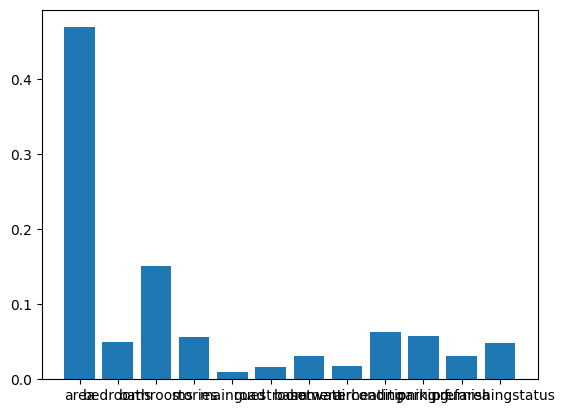

In [13]:
import matplotlib.pyplot as plt
plt.bar(x.columns,model.feature_importances_)
plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

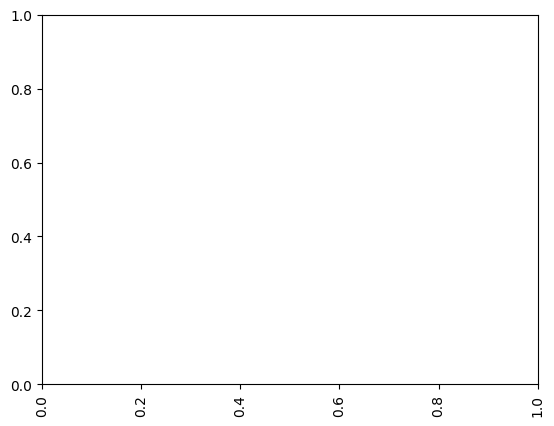

In [14]:
plt.xticks(rotation=90)